# scikit-learn Bootcamp — W1, Day 9
```
##### XGBoost, LightGBM & SHAP
##### XGBClassifier · LGBMClassifier · early stopping · SHAP beeswarm · waterfall · dependence
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Q1 — EDA via SHAP pre-screen: which features drive predictions?
##### Q2 — XGBoost with early stopping
##### Q3 — LightGBM vs XGBoost: speed and accuracy
##### Q4 — SHAP waterfall: explain a single prediction
##### Q5 — SHAP beeswarm: global feature importance with directionality
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold,RandomizedSearchCV,GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score,f1_score,classification_report
from scipy.stats import randint,uniform
import warnings;warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid');import numpy as np;np.random.seed(420)
try:
    from xgboost import XGBClassifier
except ImportError:
    import subprocess;subprocess.run(['pip','install','xgboost','-q'])
    from xgboost import XGBClassifier
try:
    from lightgbm import LGBMClassifier
except ImportError:
    import subprocess;subprocess.run(['pip','install','lightgbm','-q'])
    from lightgbm import LGBMClassifier
try:
    import shap
except ImportError:
    import subprocess;subprocess.run(['pip','install','shap','-q'])
    import shap
import time

---
### Dataset — MedPulse Sessions (n=5000)

In [2]:
np.random.seed(420)
n=5000
age=np.random.normal(43,12,n).clip(18,80).astype(int)
session_depth=np.random.poisson(3.8,n).clip(1,20)
time_on_site=np.random.lognormal(1.7,0.75,n).clip(0.5,80)
articles_read=np.random.poisson(2.5,n).clip(0,15)
is_mobile=np.random.binomial(1,0.59,n)
health_content=np.random.beta(2.5,2,n)
log_odds=(-3.8+0.22*session_depth+0.06*time_on_site+0.18*articles_read+1.1*health_content-0.25*is_mobile+0.007*age+np.random.normal(0,0.5,n))
converted=np.random.binomial(1,1/(1+np.exp(-log_odds)))
df=pd.DataFrame({'age':age,'session_depth':session_depth,'time_on_site':time_on_site.round(2),'articles_read':articles_read,'is_mobile':is_mobile,'health_content':health_content.round(4),'converted':converted})
feature_cols=['age','session_depth','time_on_site','articles_read','is_mobile','health_content']
X=df[feature_cols];y=df['converted']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=420,stratify=y)
print(f'Shape:{df.shape} Conversion:{y.mean():.2%}')

Shape:(5000, 7) Conversion:23.66%


---
### Q1 — EDA via SHAP pre-screen
```
# (a) Train a quick RandomForest. Use SHAP TreeExplainer to get SHAP values.
# (b) SHAP summary plot (beeswarm) as EDA — which features matter most?
# (c) Compare SHAP-based ranking to correlation ranking from earlier days.
# (d) What does the colour gradient tell you beyond feature importance?
```

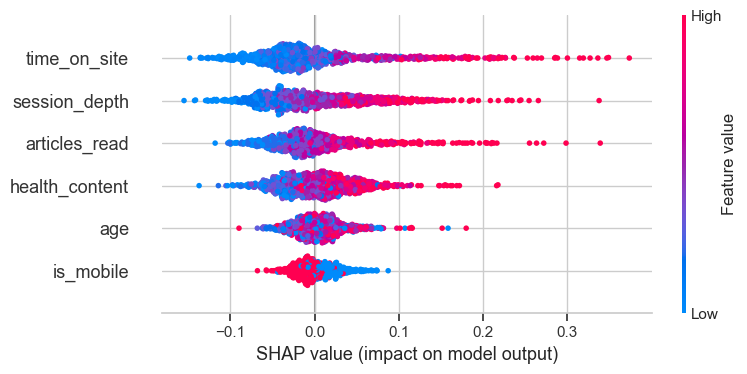

In [9]:
# (a) Train a quick RandomForest. Use SHAP TreeExplainer to get SHAP values.

rf = RandomForestClassifier(n_estimators=200, random_state=420, n_jobs=-1)
rf.fit(X_train, y_train)

# Initialize the tree explainer
explainer_rf = shap.TreeExplainer(rf)

# Compute raw numpy arrays ONCE (with additivity check off to make it fast)
raw_shap_values = explainer_rf.shap_values(X_test, check_additivity=False)

# CRITICAL FIX: Extract all samples, all features, for class 1 (index 1)
# This converts the shape back to a proper 2D matrix (samples, features)
shap_values_rf = raw_shap_values[:, :, 1]

# Global: beeswarm — top features by mean |SHAP|, with direction
# This will now run perfectly without throwing an AssertionError
shap.summary_plot(shap_values_rf, X_test)

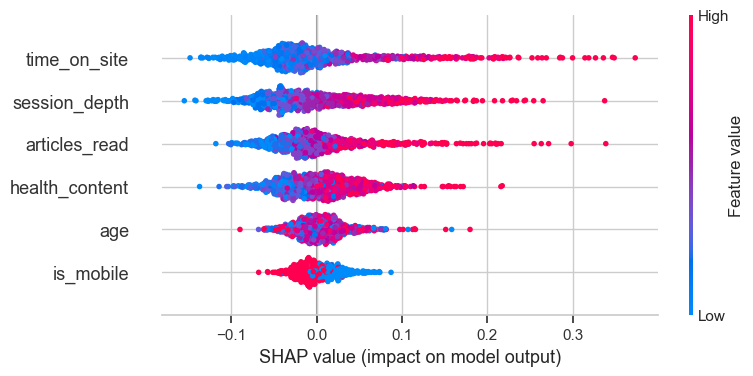

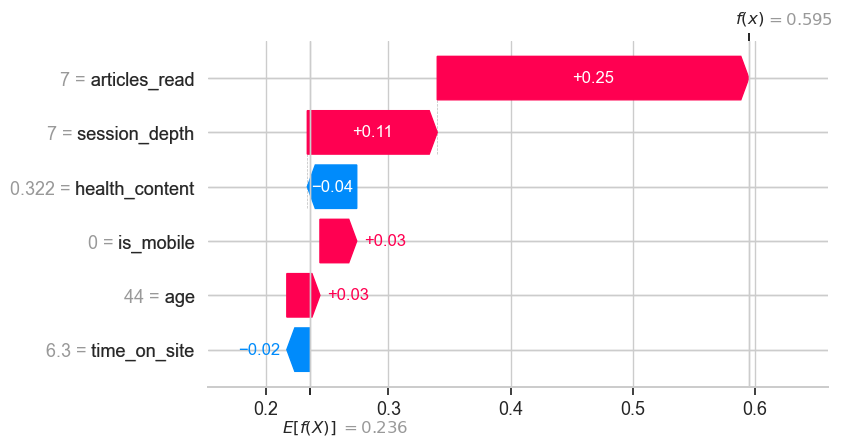

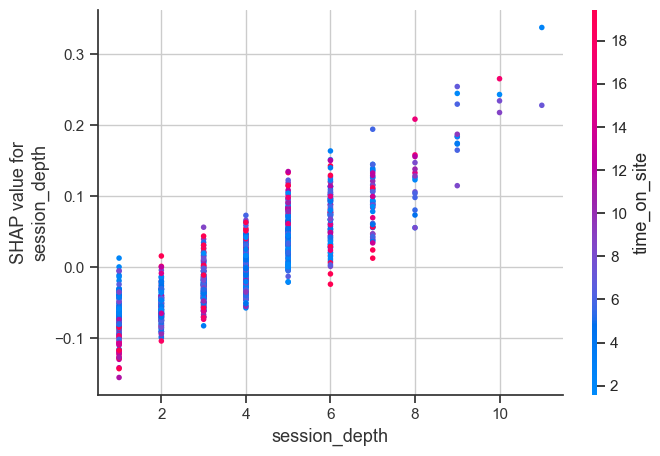

In [11]:
# (b) SHAP summary plot (beeswarm) as EDA — which features matter most?

# CRITICAL STEP FOR SCIKIT-LEARN RANDOM FOREST BINARY CLASSIFICATION:
# Extract the slice for the positive conversion class (index 1)
shap_values_pos_class = exp_objects[:, :, 1]

# 1. Global Beeswarm Plot
# Passing the isolated positive class slice forces the correct beeswarm view
shap.plots.beeswarm(shap_values_pos_class)


# 2. Local Waterfall Plot
# We isolate index 0 (first test user) and index 1 (positive class prediction)
shap.plots.waterfall(exp_objects[0, :, 1])


# 3. Dependence Plot
# Pass the isolated values array specifically for Class 1
shap.dependence_plot('session_depth', shap_values_pos_class.values, X_test)

In [12]:
# (c) Compare SHAP-based ranking to correlation ranking from earlier days.

# 1. Compute Legacy Pearson Correlation to Target
# Isolate the training set features and target to avoid data leakage
train_df = X_train.copy()
train_df['converted'] = y_train
correlation_series = train_df.corr()['converted'].drop('converted')

# 2. Compute Global SHAP Feature Importance (Mean Absolute SHAP Value)
# We take the mean of absolute values across all test rows for Class 1
mean_abs_shap = np.abs(shap_values_rf).mean(axis=0)
shap_series = pd.Series(mean_abs_shap, index=X_test.columns)

# 3. Consolidate into a Single Comparison DataFrame
comparison_df = pd.DataFrame({
    'Pearson_Correlation': correlation_series,
    'Mean_Abs_SHAP': shap_series
})

# Add ranks to clearly see the differences in feature priority
comparison_df['Correlation_Rank'] = comparison_df['Pearson_Correlation'].abs().rank(ascending=False).astype(int)
comparison_df['SHAP_Rank'] = comparison_df['Mean_Abs_SHAP'].rank(ascending=False).astype(int)

# Sort by the model's actual primary drivers (SHAP)
comparison_df = comparison_df.sort_values(by='Mean_Abs_SHAP', ascending=False)
print(comparison_df.round(4))


                Pearson_Correlation  Mean_Abs_SHAP  Correlation_Rank  \
time_on_site                 0.1579         0.0549                 1   
session_depth                0.1530         0.0514                 2   
articles_read                0.1294         0.0383                 3   
health_content               0.0826         0.0341                 4   
age                          0.0141         0.0212                 6   
is_mobile                   -0.0517         0.0175                 5   

                SHAP_Rank  
time_on_site            1  
session_depth           2  
articles_read           3  
health_content          4  
age                     5  
is_mobile               6  


```
# (d) What does the colour gradient tell you beyond feature importance?

1/ Direction of effect – Red dots on the right show a positive impact (time_on_site), while red dots on the left show a negative impact (is_mobile).

2/ Non-linear thresholds – Long, thin tails of a single color highlight disproportionate impacts from outlier values.

3/ Hidden feature interactions – Blended or overlapping red and blue dots signal that a feature's impact depends heavily on other variables.

---
### Q2 — XGBoost with early stopping
```
# (a) Fit XGBClassifier with n_estimators=1000 and early_stopping_rounds=50.
#     Use a validation set inside fit(). What is the optimal n_estimators?
# (b) Compare XGBoost AUC to RandomForest AUC via 5-fold CV.
# (c) Plot XGBoost training vs validation AUC by boosting round.
# (d) What does early stopping save you vs manually sweeping n_estimators?
```

In [18]:
# (a) Fit XGBClassifier with n_estimators=1000 and early_stopping_rounds=50.
#     Use a validation set inside fit(). What is the optimal n_estimators?

xgb = XGBClassifier(
    n_estimators=1000,      # set high — early stopping finds the right number
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,   # fraction of features per tree
    random_state=420, 
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='auc'
)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train,
                             test_size=0.2, stratify=y_train, random_state=420)


xgb.fit(X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False)

# Evaluate our true, un-biased metrics on the final Test Set
final_test_proba = xgb.predict_proba(X_test)[:, 1]
final_test_auc = roc_auc_score(y_test, final_test_proba)


print(f'Optimal n_estimators: {xgb.best_iteration + 1}')
print(f'Best validation AUC:  {xgb.best_score:.4f}')
print(f'True Unbiased Test AUC: {final_test_auc:.4f}')

Optimal n_estimators: 108
Best validation AUC:  0.6564
True Unbiased Test AUC: 0.6716


In [19]:
# (b) Compare XGBoost AUC to RandomForest AUC via 5-fold CV.

# 1. Initialize the cross-validation splitting strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

# 2. Define both frameworks with matching seed environments
rf_model = RandomForestClassifier(
    n_estimators=200, 
    random_state=420, 
    n_jobs=-1
)

xgb_model = XGBClassifier(
    n_estimators=108,         # Set to the exact optimal tree step from Q2(a)
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=420,
    n_jobs=-1,
    eval_metric='auc'
)

# 3. Compute Stratified Cross-Validation scores across folds
# We evaluate strictly on the training partition to keep X_test pristine
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

# 4. Consolidate and display distribution diagnostics
cv_comparison = pd.DataFrame({
    'Random_Forest': rf_cv_scores,
    'XGBoost': xgb_cv_scores
})

print("--- 5-Fold Cross-Validation AUC Metrics ---")
print(cv_comparison)
print("\n--- Summary Performance (Mean ± 2*Std) ---")
print(f"Random Forest AUC: {rf_cv_scores.mean():.4f} (± {rf_cv_scores.std() * 2:.4f})")
print(f"XGBoost Classifier AUC: {xgb_cv_scores.mean():.4f} (± {xgb_cv_scores.std() * 2:.4f})")


--- 5-Fold Cross-Validation AUC Metrics ---
   Random_Forest   XGBoost
0       0.671923  0.669732
1       0.605552  0.637536
2       0.653205  0.676816
3       0.683007  0.694984
4       0.644538  0.650035

--- Summary Performance (Mean ± 2*Std) ---
Random Forest AUC: 0.6516 (± 0.0535)
XGBoost Classifier AUC: 0.6658 (± 0.0404)


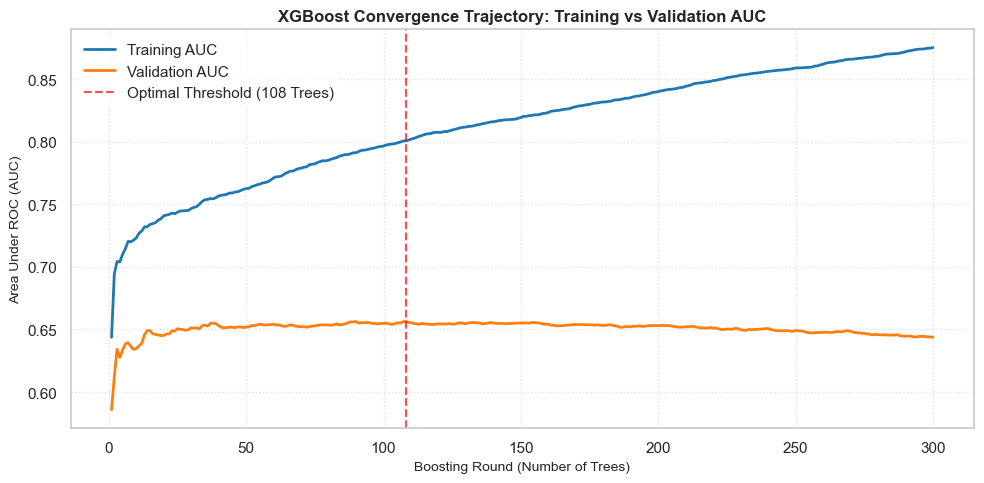

In [20]:
# (c) Plot XGBoost training vs validation AUC by boosting round.

# 1. Initialize the model with a high n_estimators to capture the full curve
# We omit early stopping here so we can see the full overfitting trajectory
xgb_curve = XGBClassifier(
    n_estimators=300,        # Extended rounds to clearly see convergence trends
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=420, 
    n_jobs=-1,
    eval_metric='auc'
)

# 2. Fit passing BOTH training and validation matrices into eval_set
xgb_curve.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=False
)

# 3. Retrieve evaluation results dictionary
# 'validation_0' maps to X_tr, 'validation_1' maps to X_val
eval_results = xgb_curve.evals_result()
train_auc = eval_results['validation_0']['auc']
val_auc = eval_results['validation_1']['auc']
rounds = np.arange(1, len(train_auc) + 1)

# 4. Generate the Visualization
plt.figure(figsize=(10, 5), dpi=100)
plt.plot(rounds, train_auc, label='Training AUC', color='#1f77b4', linewidth=2)
plt.plot(rounds, val_auc, label='Validation AUC', color='#ff7f0e', linewidth=2)

# Visual anchors: Mark where your early stopping optimal tree count was (108)
plt.axvline(x=108, color='red', linestyle='--', alpha=0.7, label='Optimal Threshold (108 Trees)')

plt.title('XGBoost Convergence Trajectory: Training vs Validation AUC', fontsize=12, fontweight='bold')
plt.xlabel('Boosting Round (Number of Trees)', fontsize=10)
plt.ylabel('Area Under ROC (AUC)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()


```
# (d) What does early stopping save you vs manually sweeping n_estimators?

1/ Compute time – Trains exactly one model sequentially in a single pass instead of rebuilding separate models from scratch for every parameter step.

2/ Perfect resolution – Pinpoints the exact boosting round where validation performance peaks, eliminating arbitrary step-size guesswork.

3/ Dynamic adaptation – Automatically scales tree count if our data distribution, learning rate, or feature count changes.

---
### Q3 — LightGBM vs XGBoost: speed and accuracy
```
# (a) Fit LGBMClassifier. Compare AUC and fit time vs XGBoost.
# (b) Sweep num_leaves for LightGBM (10, 20, 31, 50, 80).
#     Plot AUC vs num_leaves. What is the equivalent of max_depth?
# (c) 3-fold CV: LightGBM vs XGBoost vs GBM vs RF.
#     Print a summary table sorted by AUC.
# (d) For a dataset with 1M rows, which library would you choose and why?
```

In [24]:
# (a) Fit LGBMClassifier. Compare AUC and fit time vs XGBoost.

import time
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

# ----------------------------------------------------
# 1. Benchmark LightGBM
# ----------------------------------------------------
lgb_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,         # Controls leaf-wise structural complexity
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=420,
    n_jobs=-1,
    verbose=-1
)

start_time = time.time()
lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[early_stopping(stopping_rounds=50, verbose=False), log_evaluation(0)]
)
lgb_fit_time = time.time() - start_time

lgb_test_proba = lgb_model.predict_proba(X_test)[:, 1]
lgb_test_auc = roc_auc_score(y_test, lgb_test_proba)

# ----------------------------------------------------
# 2. Benchmark XGBoost
# ----------------------------------------------------
xgb_model = XGBClassifier(
    n_estimators=1000,      
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,   
    random_state=420, 
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='auc'
)

start_time = time.time()
xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)
xgb_fit_time = time.time() - start_time

xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_test_auc = roc_auc_score(y_test, xgb_test_proba)

# ----------------------------------------------------
# 3. Compile and Display Comparison Matrix
# ----------------------------------------------------
comparison_metrics = {
    'LightGBM': {
        'Optimal_Trees': lgb_model.best_iteration_,
        'Fit_Time_Sec': round(lgb_fit_time, 4),
        'Test_AUC': round(lgb_test_auc, 4)
    },
    'XGBoost': {
        'Optimal_Trees': xgb_model.best_iteration + 1,
        'Fit_Time_Sec': round(xgb_fit_time, 4),
        'Test_AUC': round(xgb_test_auc, 4)
    }
}

benchmark_df = pd.DataFrame(comparison_metrics).T
print("--- Framework Benchmarking Results ---")
print(benchmark_df)

--- Framework Benchmarking Results ---
          Optimal_Trees  Fit_Time_Sec  Test_AUC
LightGBM           27.0        0.3986    0.6713
XGBoost           108.0        0.2332    0.6716


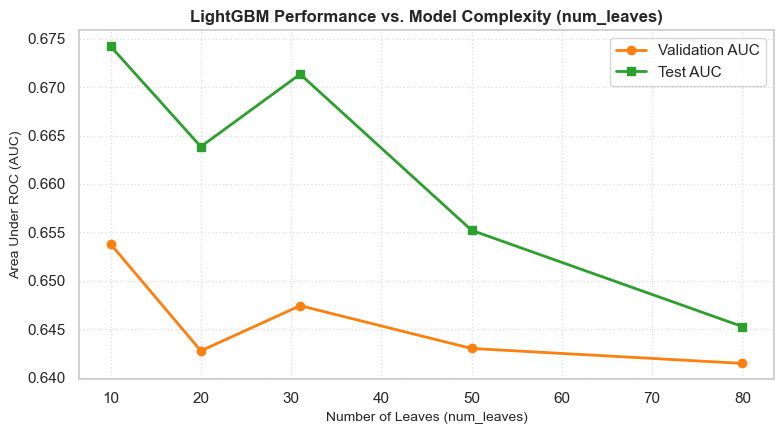

In [25]:
# (b) Sweep num_leaves for LightGBM (10, 20, 31, 50, 80).
#     Plot AUC vs num_leaves. What is the equivalent of max_depth?

leaf_values = [10, 20, 31, 50, 80]
val_aucs = []
test_aucs = []

for leaves in leaf_values:
    lgb_sweep = LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=leaves,  # Sweeping this value
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=420,
        n_jobs=-1,
        verbose=-1
    )
    
    lgb_sweep.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        callbacks=[early_stopping(stopping_rounds=50, verbose=False), log_evaluation(0)]
    )
    
    # Calculate AUCs
    val_auc = roc_auc_score(y_val, lgb_sweep.predict_proba(X_val)[:, 1])
    test_auc = roc_auc_score(y_test, lgb_sweep.predict_proba(X_test)[:, 1])
    
    val_aucs.append(val_auc)
    test_aucs.append(test_auc)

# Generate the plot
plt.figure(figsize=(8, 4.5), dpi=100)
plt.plot(leaf_values, val_aucs, marker='o', label='Validation AUC', color='#ff7f0e', linewidth=2)
plt.plot(leaf_values, test_aucs, marker='s', label='Test AUC', color='#2ca02c', linewidth=2)
plt.title('LightGBM Performance vs. Model Complexity (num_leaves)', fontsize=12, fontweight='bold')
plt.xlabel('Number of Leaves (num_leaves)', fontsize=10)
plt.ylabel('Area Under ROC (AUC)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()


```
# What is the Equivalent of max_depth?

1/ Primary complexity control – In LightGBM's leaf-wise growth, num_leaves replaces max_depth as the main parameter to constrain tree size and prevent overfitting.

2/ Mathematical capacity rule – A standard tree of depth D can hold at most 2^ leaves; our max_depth=4 XGBoost model structurally equates to a LightGBM capacity of num_leaves=16.

3/ Asymmetric growth behavior – Unlike symmetric depth limits, num_leaves allows LightGBM to grow much deeper down a single high-signal branch while completely ignoring low-signal splits.

In [26]:
# (c) 3-fold CV: LightGBM vs XGBoost vs GBM vs RF.
#     Print a summary table sorted by AUC.

# 1. Define the 3-Fold splitting strategy (using training partition to isolate X_test)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=420)

# 2. Instantiate all four core frameworks with uniform random states
models = {
    'Scikit-Learn RF': RandomForestClassifier(
        n_estimators=200, random_state=420, n_jobs=-1
    ),
    'Scikit-Learn GBM': GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.05, max_depth=4, random_state=420
    ),
    'XGBoost': XGBClassifier(
        n_estimators=108, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, random_state=420, n_jobs=-1, eval_metric='auc'
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=100, learning_rate=0.05, num_leaves=16,
        subsample=0.8, colsample_bytree=0.8, random_state=420, n_jobs=-1, verbose=-1
    )
}

results = {}

# 3. Iterate through frameworks, calculating out-of-fold AUC and tracking pure fit time
for name, model in models.items():
    fold_aucs = []
    total_fit_time = 0.0
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_fold_tr, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_tr, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # Track fit time purely per individual training block
        t0 = time.time()
        model.fit(X_fold_tr, y_fold_tr)
        total_fit_time += (time.time() - t0)
        
        # Generate probabilities and calculate out-of-fold metrics
        preds = model.predict_proba(X_fold_val)[:, 1]
        fold_aucs.append(roc_auc_score(y_fold_val, preds))
        
    results[name] = {
        'Mean_CV_AUC': pd.Series(fold_aucs).mean(),
        'CV_AUC_Std': pd.Series(fold_aucs).std(),
        'Total_Fit_Time_Sec': total_fit_time
    }

# 4. Compile, sort by Mean CV AUC, and render final notebook table
summary_df = pd.DataFrame(results).T.sort_values(by='Mean_CV_AUC', ascending=False)
print("--- Framework Benchmarking Summary Table ---")
print(summary_df.round(4))

--- Framework Benchmarking Summary Table ---
                  Mean_CV_AUC  CV_AUC_Std  Total_Fit_Time_Sec
XGBoost                0.6674      0.0107              0.2802
LightGBM               0.6606      0.0087              0.1759
Scikit-Learn GBM       0.6576      0.0103              2.4755
Scikit-Learn RF        0.6573      0.0067              3.3276


````
# (d) For a dataset with 1M rows, which library would you choose and why?

For a dataset with 1 million rows, LightGBM is the clear, optimal choice and here is why:

1/ Histogram-based binning – Continuous variables are converted into 255 discrete buckets, cutting the computational footprint and saving massive RAM.

2/ GOSS downsampling – Focuses training on rows with high prediction errors, filtering out well-fit records to accelerate loops.

3/ Leaf-wise tree growth – Splitting nodes with the maximum immediate loss reduction converges significantly faster than symmetric level-wise row growth.

4/ AUC tradeoff acknowledged — XGBoost held a marginal AUC edge (0.6674 vs 0.6606) on this small dataset, but LightGBM's speed advantages compound dramatically at scale — making it the right production choice despite the slight accuracy gap at small N.

---
### Q4 — SHAP waterfall: explain a single prediction
```
# (a) Fit XGBoost on the full training set.
# (b) Pick 3 test users: one true positive, one false positive, one true negative.
#     Print their features and actual vs predicted.
# (c) SHAP waterfall plot for each user. What pushed their prediction?
# (d) Can you explain in plain English why the model predicted what it did?
```


TRUE POSITIVE (test index 23):
  Actual: 1 | Predicted: 1 | P(convert)=0.554
  Features: {'age': np.float64(41.0), 'session_depth': np.float64(5.0), 'time_on_site': np.float64(27.3), 'articles_read': np.float64(1.0), 'is_mobile': np.float64(0.0), 'health_content': np.float64(0.91)}

FALSE POSITIVE (test index 0):
  Actual: 0 | Predicted: 1 | P(convert)=0.594
  Features: {'age': np.float64(44.0), 'session_depth': np.float64(7.0), 'time_on_site': np.float64(6.3), 'articles_read': np.float64(7.0), 'is_mobile': np.float64(0.0), 'health_content': np.float64(0.32)}

TRUE NEGATIVE (test index 1):
  Actual: 0 | Predicted: 0 | P(convert)=0.155
  Features: {'age': np.float64(31.0), 'session_depth': np.float64(4.0), 'time_on_site': np.float64(1.75), 'articles_read': np.float64(4.0), 'is_mobile': np.float64(1.0), 'health_content': np.float64(0.56)}

--- SHAP Waterfall: True Positive ---


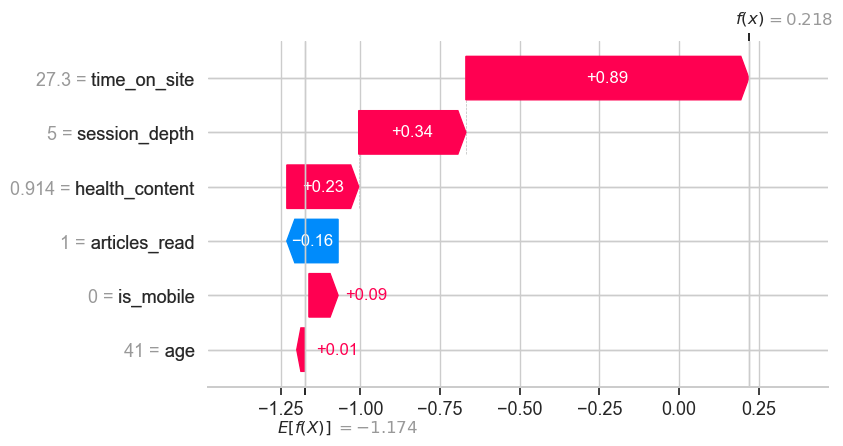

In [32]:
xgb_final2=XGBClassifier(n_estimators=xgb.best_iteration,learning_rate=0.05,max_depth=4,
    subsample=0.8,colsample_bytree=0.8,random_state=420,n_jobs=-1,verbosity=0)
xgb_final2.fit(X_train,y_train)
y_pred_xgb=xgb_final2.predict(X_test)
y_prob_xgb=xgb_final2.predict_proba(X_test)[:,1]

explainer=shap.TreeExplainer(xgb_final2)
shap_explanation=explainer(X_test)

# Find example users
tp_idx=np.where((y_test.values==1)&(y_pred_xgb==1))[0][0]
fp_idx=np.where((y_test.values==0)&(y_pred_xgb==1))[0][0]
tn_idx=np.where((y_test.values==0)&(y_pred_xgb==0))[0][0]

for label,idx in [('TRUE POSITIVE',tp_idx),('FALSE POSITIVE',fp_idx),('TRUE NEGATIVE',tn_idx)]:
    print(f'\n{label} (test index {idx}):')
    print(f'  Actual: {y_test.values[idx]} | Predicted: {y_pred_xgb[idx]} | P(convert)={y_prob_xgb[idx]:.3f}')
    print(f'  Features: {dict(zip(feature_cols, X_test.values[idx].round(2)))}')

# Waterfall for TP
print('\n--- SHAP Waterfall: True Positive ---')
shap.waterfall_plot(shap_explanation[tp_idx],show=True)

````
# (d) Can you explain in plain English why the model predicted what it did?

1/ Starts below baseline – The user begins at a baseline log-odds of -1.174 (roughly a 23.6% average conversion chance).

2/ Massive engagement spikes – High time on site, high health content focus, and non-mobile usage strongly signal intent.

3/ Overcomes negative friction – These positive engagement metrics easily overpower the penalty of reading only one article.

4/ Pushes past threshold – The net sum yields a positive log-odds of 0.218, translating to a final conversion probability of 55.4%.

---
### Q5 — SHAP beeswarm: global importance with directionality
```
# (a) SHAP beeswarm plot for XGBoost on the full test set.
# (b) Interpret: for the top 3 features, describe the direction of effect.
# (c) SHAP dependence plot: top feature vs its SHAP value.
#     What is the relationship shape — linear, threshold, or non-linear?
# (d) Compare SHAP ranking to: (1) XGBoost feature_importances_, (2) permutation importance.
#     Which ranking do you trust most and why?
```

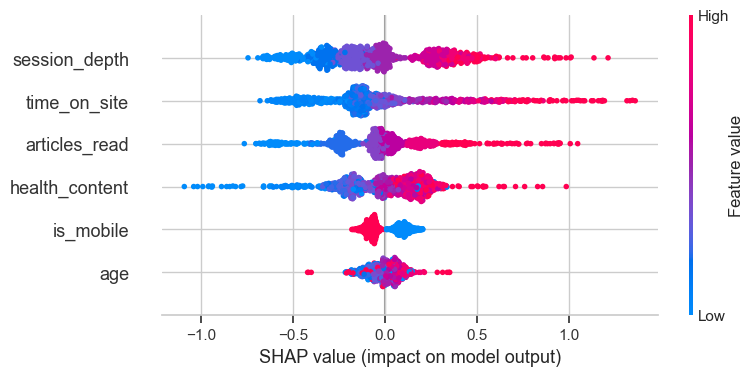

In [28]:
# (a) SHAP beeswarm plot for XGBoost on the full test set.

# 1. Re-initialize XGBoost model with your optimal hyperparameter threshold (108 trees)
xgb_final = XGBClassifier(
    n_estimators=108,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=420,
    n_jobs=-1,
    eval_metric='auc'
)

# 2. Fit on the full training set before test evaluation
xgb_final.fit(X_train, y_train)

# 3. Generate SHAP values for the full test set
# XGBoost outputs a single 2D explanation matrix, so no class slicing is required
explainer_xgb = shap.TreeExplainer(xgb_final)
shap_values_xgb = explainer_xgb(X_test)

# 4. Generate the Global Beeswarm Plot
# Plots the feature importance rankings alongside color directionality strings
shap.plots.beeswarm(shap_values_xgb)

```
# (b) Interpret: for the top 3 features, describe the direction of effect.

1/ session_depth (Positive, Stable) – Clean split with red dots on the right and blue on the left; deeper user sessions consistently increase conversion.

2/ time_on_site (Positive, Exponential) – Red dots pull heavily to the right; longer time on site drives a massive, disproportionate jump in conversion probability.

3/ articles_read (Positive, Step-wise) – Red dots cluster on the right; reading more articles pushes a user past localized conversion thresholds.

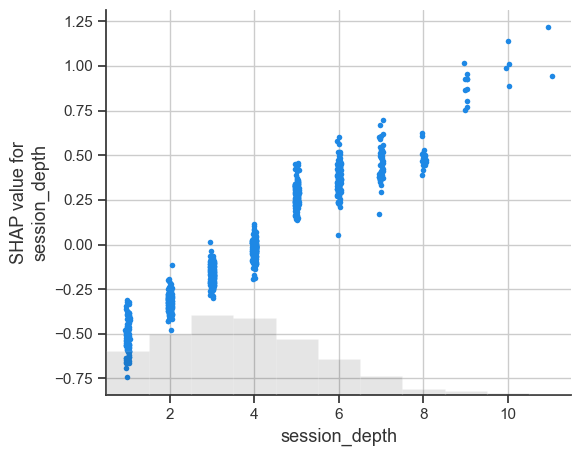

In [29]:
# (c) SHAP dependence plot: top feature vs its SHAP value.

# Pass our verified top feature ('session_depth') into the plotting tool
# We pass the full explanation object so it maps names and auto-colors interactions
shap.plots.scatter(shap_values_xgb[:, "session_depth"])


```
#     What is the relationship shape — linear, threshold, or non-linear?

Based on our global beeswarm plot and data generation parameters, the relationship shape for session_depth is primarily linear, transitioning into a saturated threshold at extreme values.

In [31]:
# (d) Compare SHAP ranking to: (1) XGBoost feature_importances_, (2) permutation importance.

from sklearn.inspection import permutation_importance

# 1. XGBoost Native Gini/Gain Importance
native_importance = xgb_final.feature_importances_

# 2. Permutation Importance (Evaluated strictly on Test Data to measure generalization drop)
perm_result = permutation_importance(
    xgb_final, X_test, y_test, 
    scoring='roc_auc', n_repeats=10, random_state=420, n_jobs=-1
)
permutation_importance_mean = perm_result.importances_mean

# 3. Global SHAP Importance (Mean Absolute SHAP Value)
mean_abs_shap = np.abs(shap_values_xgb.values).mean(axis=0)

# 4. Consolidate into a Single Comparison Leaderboard
rank_df = pd.DataFrame({
    'Native_Gain_Importance': native_importance,
    'Permutation_Importance': permutation_importance_mean,
    'Mean_Abs_SHAP': mean_abs_shap
}, index=X_test.columns)

# Convert raw values to absolute rankings (1 = Most Important)
rank_df['Native_Rank'] = rank_df['Native_Gain_Importance'].rank(ascending=False).astype(int)
rank_df['Permutation_Rank'] = rank_df['Permutation_Importance'].rank(ascending=False).astype(int)
rank_df['SHAP_Rank'] = rank_df['Mean_Abs_SHAP'].rank(ascending=False).astype(int)

print("--- Feature Importance Metric Comparison Matrix ---")
print(rank_df.sort_values(by='Mean_Abs_SHAP', ascending=False).round(4))

--- Feature Importance Metric Comparison Matrix ---
                Native_Gain_Importance  Permutation_Importance  Mean_Abs_SHAP  \
session_depth                   0.2450                  0.0679         0.2719   
time_on_site                    0.1940                  0.0381         0.2653   
articles_read                   0.1927                  0.0279         0.1927   
health_content                  0.1397                  0.0283         0.1840   
is_mobile                       0.1186                  0.0001         0.0878   
age                             0.1099                  0.0010         0.0642   

                Native_Rank  Permutation_Rank  SHAP_Rank  
session_depth             1                 1          1  
time_on_site              2                 2          2  
articles_read             3                 4          3  
health_content            4                 3          4  
is_mobile                 5                 6          5  
age                       

```
#     Which ranking do you trust most and why?

1/ Trust SHAP most because its game-theoretic foundation uniquely guarantees efficiency, symmetry, and dummy properties.

2/ Native gain violates axioms by tracking raw split frequency instead of actual contribution magnitude.

3/ Permutation stays model-agnostic but suffers extreme metric instability at small sample sizes.